In [20]:
!pip install kagglehub

In [21]:
# =========================
# 1. Import Libraries
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import kagglehub
import os


In [22]:

# =========================
# 2. Download Dataset
# =========================
path = kagglehub.dataset_download("praneet0327/brain-tumor-dataset")
print("Dataset Path:", path)

# =========================
# 3. Set Correct Path
# =========================
dataset_path = path + "/Brain_Tumor_Dataset"
print("Folders:", os.listdir(dataset_path))

Dataset Path: C:\Users\Admin\.cache\kagglehub\datasets\praneet0327\brain-tumor-dataset\versions\1
Folders: ['Negative', 'Positive']


In [23]:


# =========================
# 4. Load Dataset
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 5266 files belonging to 2 classes.
Using 4213 files for training.
Found 5266 files belonging to 2 classes.
Using 1053 files for validation.
Classes: ['Negative', 'Positive']


In [24]:


# =========================
# 5. Normalize
# =========================
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

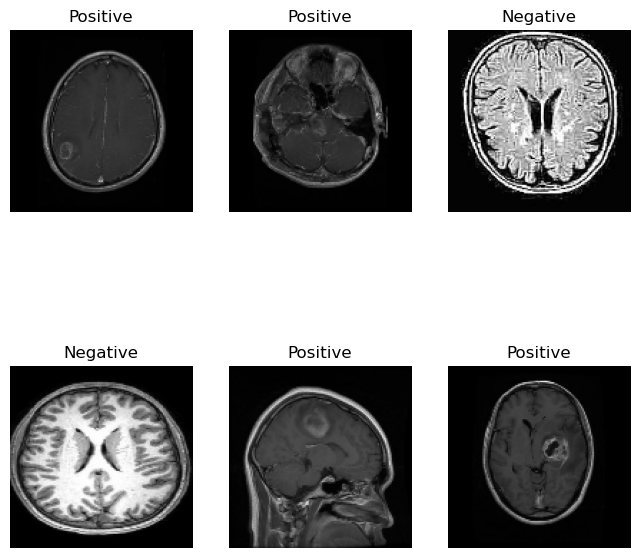

In [25]:
# =========================
# 6. Visualize
# =========================
plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [26]:
# =========================
# 7. Data Augmentation
# =========================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [27]:


# =========================
# 8. CNN Model
# =========================
model = keras.Sequential([
    
    data_augmentation,

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])


In [28]:

# =========================
# 9. Compile
# =========================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:


# =========================
# 10. Train
# =========================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 48s 344ms/step - accuracy: 0.8614 - loss: 0.3259 - val_accuracy: 0.8822 - val_loss: 0.2969
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 276ms/step - accuracy: 0.9243 - loss: 0.1967 - val_accuracy: 0.8433 - val_loss: 0.4045
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 42s 319ms/step - accuracy: 0.9338 - loss: 0.1706 - val_accuracy: 0.8167 - val_loss: 0.4242
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 50s 382ms/step - accuracy: 0.9447 - loss: 0.1441 - val_accuracy: 0.9449 - val_loss: 0.1635
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 56s 422ms/step - accuracy: 0.9452 - loss: 0.1379 - val_accuracy: 0.8604 - val_loss: 0.3313
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 43s 328ms/step - accuracy: 0.9516 - loss: 0.1185 - val_accuracy: 0.9297 - val_loss: 0.1837
Epoch 7/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 40s 304ms/step - accuracy: 0.9516 - loss: 0.1243 - val_accuracy: 0.9202 - val_loss: 0.2161


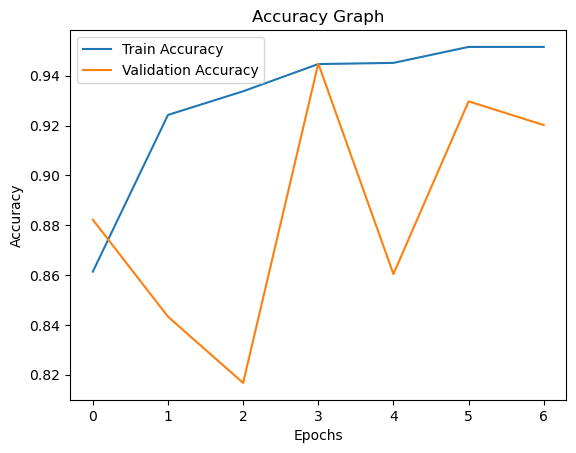

In [30]:


# =========================
# 11. Accuracy Graph
# =========================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

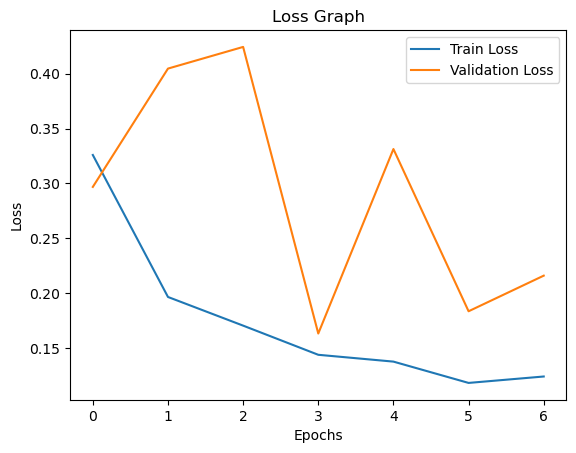

In [31]:


# =========================
# 12. Loss Graph
# =========================
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [32]:


# =========================
# 13. Save Model
# =========================
model.save("brain_tumor_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

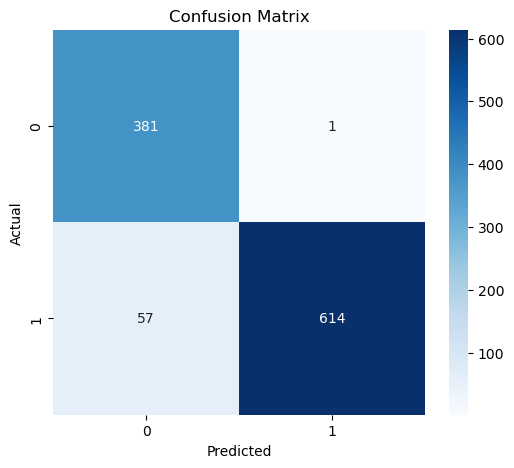

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       382
           1       1.00      0.92      0.95       671

    accuracy                           0.94      1053
   macro avg       0.93      0.96      0.94      1053
weighted avg       0.95      0.94      0.95      1053



In [33]:
# =========================
# 14. Confusion Matrix
# =========================
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))